# Data Exploration and Processing before Training

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import xgboost as xgb
import os
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pathlib import Path

# Load the dataset
root_dir = Path().resolve().parent
data_path = root_dir / 'data' / 'adult.csv'
data = pd.read_csv(data_path, delimiter=',')

# Drop 'fnlwgt' column as it's not needed for analysis
data.drop('fnlwgt', axis=1, inplace=True)

# Replace '?' with NaN
data.replace('?', np.nan, inplace=True)

# Display the first 5 rows of the dataset
data.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
# See all education levels and their numeric mappings
education_mapping = data[['education', 'education.num']].drop_duplicates().sort_values('education.num')
print(education_mapping)

         education  education.num
1106     Preschool              1
26         1st-4th              2
27         5th-6th              3
3          7th-8th              4
197            9th              5
6             10th              6
16            11th              7
178           12th              8
0          HS-grad              9
2     Some-college             10
25       Assoc-voc             11
18      Assoc-acdm             12
12       Bachelors             13
13         Masters             14
11     Prof-school             15
7        Doctorate             16


In [8]:
data['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   education       32561 non-null  str  
 3   education.num   32561 non-null  int64
 4   marital.status  32561 non-null  str  
 5   occupation      30718 non-null  str  
 6   relationship    32561 non-null  str  
 7   race            32561 non-null  str  
 8   sex             32561 non-null  str  
 9   capital.gain    32561 non-null  int64
 10  capital.loss    32561 non-null  int64
 11  hours.per.week  32561 non-null  int64
 12  native.country  31978 non-null  str  
 13  income          32561 non-null  str  
dtypes: int64(5), str(9)
memory usage: 5.9 MB


In [10]:
categorical_cols = data.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')


/var/folders/rw/rpjmzd6n0j14gfcnpzfl_ng00000gn/T/ipykernel_59891/1146110634.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=["object"]).columns


# Train / Test split of dataset

In [11]:
# Separate features and target variable
X = data.drop(['income', 'education'], axis=1)

# Label encode target variable
le = LabelEncoder()
y = le.fit_transform(data['income'])

print('Classes:', y[:5])
X

Classes: [0 0 0 0 0]


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,NaN,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,NaN,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States
32557,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32558,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32559,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States


In [12]:
# Categorical and numerical columns
categorical_cols = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
numerical_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

# ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# Create pipeline with preprocessor and XGBoost model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=260, max_depth=6, learning_rate=0.05, objective='binary:logistic'))
])

print(pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('model',
       

In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transform train/test data for eval_set
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Fit model
start_time = time.time()
pipeline.fit(X_train, y_train, model__eval_set=[(X_train_transformed, y_train), (X_test_transformed, y_test)], model__verbose=False)
training_time = time.time() - start_time

# Predict on the test set
start_time = time.time()
y_pred = pipeline.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Training Time: {training_time:.2f} seconds')
print(f'Prediction Time: {prediction_time:.2f} seconds')
print(f'Accuracy: {accuracy:.4f}')

# Confusion Matrix
print("\nConfusion Matrix: ")
print(f"                Predicted <=50k (0)  Predicted >50k (1)")
print(f"Actual <=50k (0)       {conf_matrix[0][0]:5d}                    {conf_matrix[0][1]:5d}")
print(f"Actual >50k (1)        {conf_matrix[1][0]:5d}                    {conf_matrix[1][1]:5d}")

print(f"\nTrue Negative: {conf_matrix[0][0]}")
print(f"False Positive: {conf_matrix[0][1]}")
print(f"False Negative: {conf_matrix[1][0]}")
print(f"True Positive: {conf_matrix[1][1]}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Time: 1.82 seconds
Prediction Time: 0.03 seconds
Accuracy: 0.8730

Confusion Matrix: 
                Predicted <=50k (0)  Predicted >50k (1)
Actual <=50k (0)        4728                      248
Actual >50k (1)          579                      958

True Negative: 4728
False Positive: 248
False Negative: 579
True Positive: 958

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4976
           1       0.79      0.62      0.70      1537

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513



In [14]:
print(X_train.shape)
print(X_test.shape)


(26048, 12)
(6513, 12)


# Plots and Graphs

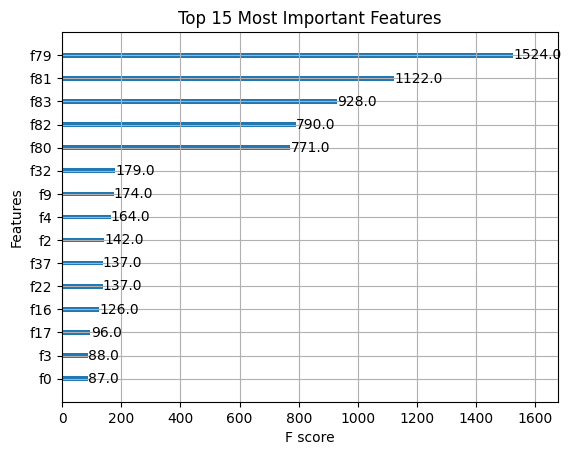

In [15]:
# Plot importance of features
xgb.plot_importance(pipeline['model'], max_num_features=15)
plt.title('Top 15 Most Important Features')
plt.show()

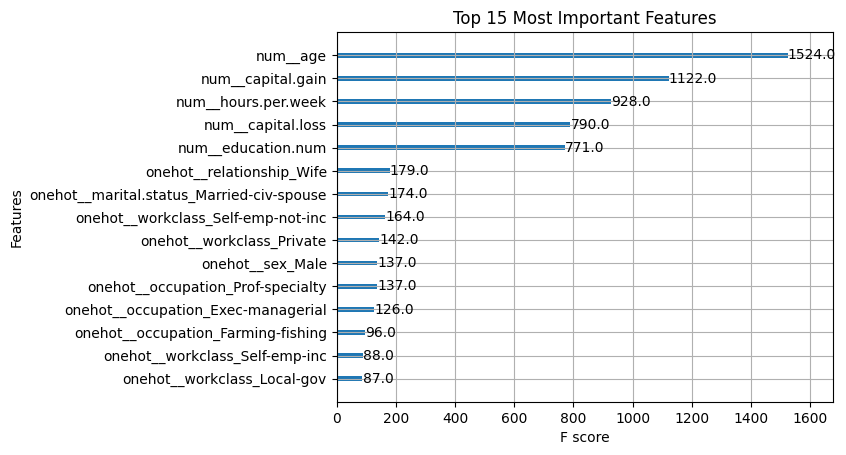

In [16]:
# Plot importance of features with category names
feature_names = pipeline['preprocessor'].get_feature_names_out()
pipeline['model'].get_booster().feature_names = list(feature_names)

xgb.plot_importance(pipeline['model'], max_num_features=15)
plt.title('Top 15 Most Important Features')
plt.show()

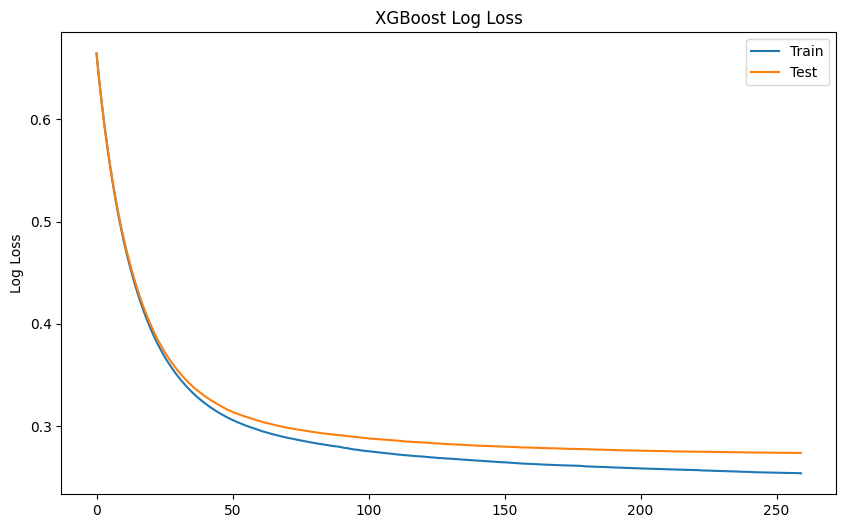

In [17]:
# Plot to show if there's overfitting
results = pipeline['model'].evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.legend()
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.show()

In [12]:
# Save the model
model_path = root_dir / 'models' / 'xgb_pipeline.joblib'
joblib.dump(pipeline, model_path)

print(f'Model saved in model directory')

Model saved in model directory


In [13]:
# Save X_test and y_test
X_test.to_csv(root_dir / 'data' / 'X_test.csv', index=False)
pd.Series(y_test, name='income').to_csv(root_dir / 'data' / 'y_test.csv', index=False)

print(f'Test data saved in data directory')

Test data saved in data directory


In [19]:
# Save background sample for SHAP
from sklearn.pipeline import Pipeline

x_background = pipeline.named_steps['preprocessor'].transform(X_train).toarray()
background_sample = x_background[np.random.choice(x_background.shape[0], 500, replace=False)]

joblib.dump(background_sample, root_dir / 'data' / 'background_sample.joblib')
print(f'Background sample saved in data directory')

Background sample saved in data directory


In [14]:
print(xgb.__version__)

1.7.6
